<a href="https://colab.research.google.com/github/VoRtExxs/Final-Project-trojan-detector/blob/main/Phase2_EDA_ASD_Toddler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Exploratory Data Analysis — ASD Toddler Screening Dataset
## Project: Early ASD Detection Using Classical ML
**Dataset:** Thabtah, F. (2018). Autism Screening Data for Toddlers. Kaggle.  
**Screening Tool:** Q-CHAT-10 (ages 16–30 months)  
**Target:** Binary classification — ASD traits Yes/No  
**Models Planned:** SVM + Logistic Regression + SHAP  
**Author:** [Abdulrahman.K.I.Almansi]  
**Date:** May 2026  

---
### EDA Goals:
1. Understand every column clinically and technically
2. Detect missing values, encoding issues, class imbalance
3. Visualize feature distributions and relationships
4. Document findings for the paper's Methods/Data section

In [ ]:
# ============================================================
# CELL 2: Import Libraries
# ------------------------------------------------------------
# WHY: We need these tools for every step of our EDA.
# - pandas: load and manipulate the dataset (our main tool)
# - numpy: numerical operations
# - matplotlib/seaborn: visualizations for the paper
# - warnings: suppress minor warnings to keep output clean
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set plot style — clean and paper-ready
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")
print(f"   pandas  version: {pd.__version__}")
print(f"   numpy   version: {np.__version__}")
print(f"   seaborn version: {sns.__version__}")

✅ All libraries imported successfully!
   pandas  version: 2.2.2
   numpy   version: 2.0.2
   seaborn version: 0.13.2


In [ ]:
# ============================================================
# CELL 3: Load the Dataset
# ------------------------------------------------------------
# WHY: We load the CSV into a pandas DataFrame — this is the
# object we'll work with for all our analysis.
# The file path starts with /content/ in Google Colab because
# that's where uploaded files are stored.
# ============================================================

# Load dataset
df = pd.read_csv('/content/Toddler Autism dataset July 2018.csv')

# First confirmation: did it load correctly?
print("✅ Dataset loaded successfully!")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print(f"\n📋 Column names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2}. {col}")

✅ Dataset loaded successfully!
   Rows    : 1054
   Columns : 19

📋 Column names:
    1. Case_No
    2. A1
    3. A2
    4. A3
    5. A4
    6. A5
    7. A6
    8. A7
    9. A8
   10. A9
   11. A10
   12. Age_Mons
   13. Qchat-10-Score
   14. Sex
   15. Ethnicity
   16. Jaundice
   17. Family_mem_with_ASD
   18. Who completed the test
   19. Class/ASD Traits 


In [ ]:
# ============================================================
# CELL 4: First Deep Inspection
# ------------------------------------------------------------
# WHY: Before touching any data, we need to understand:
# 1. What does the data actually look like? (first rows)
# 2. What data type is each column? (int, float, object)
# 3. Are there any missing values?
#
# CLINICAL CONNECTION: In clinical research, this step is
# equivalent to reviewing your data collection forms before
# analysis — you must know what you have before interpreting.
# ============================================================

print("=" * 60)
print("STEP 4A: First 5 rows of the dataset")
print("=" * 60)
display(df.head())

print("\n")
print("=" * 60)
print("STEP 4B: Data types and non-null counts")
print("=" * 60)
df.info()

print("\n")
print("=" * 60)
print("STEP 4C: Missing values per column")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
# Only show columns that have missing values
missing_report = missing_df[missing_df['Missing Count'] > 0]

if len(missing_report) == 0:
    print("✅ No missing values (NaN) detected.")
    print("⚠️  NOTE: Some columns may use '?' for unknown values.")
    print("    We will check for '?' in Cell 5.")
else:
    print(missing_report)

print("\n")
print("=" * 60)
print("STEP 4D: Unique values per column (quick summary)")
print("=" * 60)
for col in df.columns:
    unique_vals = df[col].unique()
    n = len(unique_vals)
    # Show all unique values if few, otherwise show count
    if n <= 10:
        print(f"  {col:30} → {n} unique: {sorted([str(v) for v in unique_vals])}")
    else:
        print(f"  {col:30} → {n} unique values (continuous/high cardinality)")

STEP 4A: First 5 rows of the dataset


,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes




STEP 4B: Data types and non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Case_No                 1054 non-null   int64 
 1   A1                      1054 non-null   int64 
 2   A2                      1054 non-null   int64 
 3   A3                      1054 non-null   int64 
 4   A4                      1054 non-null   int64 
 5   A5                      1054 non-null   int64 
 6   A6                      1054 non-null   int64 
 7   A7                      1054 non-null   int64 
 8   A8                      1054 non-null   int64 
 9   A9                      1054 non-null   int64 
 10  A10                     1054 non-null   int64 
 11  Age_Mons                1054 non-null   int64 
 12  Qchat-10-Score          1054 non-null   int64 
 13  Sex                     1054 non-null   object
 14  Ethnicity     

In [ ]:
df.columns = df.columns.str.strip()
# ============================================================
# CELL 5: Hunt for Hidden Problems
# ------------------------------------------------------------
# WHY: Real-world datasets often encode missing values as
# '?', 'unknown', 'Unknown', or empty strings instead of
# NaN. Pandas won't catch these automatically — we must
# look manually.
#
# We also fix the dirty 'Who completed the test' column here.
#
# CLINICAL CONNECTION: In clinical data, messy categorical
# values are extremely common — different data entry staff
# use different conventions. Cleaning this is essential
# before any statistical or ML analysis.
# ============================================================

print("=" * 60)
print("STEP 5A: Scan ALL columns for '?' values")
print("=" * 60)
for col in df.columns:
    count = (df[col] == '?').sum()
    if count > 0:
        print(f"  ⚠️  {col}: {count} '?' values found")
    else:
        print(f"  ✅ {col}: clean")

print("\n")
print("=" * 60)
print("STEP 5B: Full value counts — Ethnicity")
print("=" * 60)
print(df['Ethnicity'].value_counts())

print("\n")
print("=" * 60)
print("STEP 5C: Full value counts — Who completed the test")
print("=" * 60)
print(df['Who completed the test'].value_counts())

print("\n")
print("=" * 60)
print("STEP 5D: Fix dirty category in 'Who completed the test'")
print("=" * 60)
# Standardize to lowercase then title case
df['Who completed the test'] = df['Who completed the test'].str.strip().str.lower()

# Map to clean standard labels
who_mapping = {
    'family member'             : 'Family Member',
    'health care professional'  : 'Health Care Professional',
    'self'                      : 'Self',
    'others'                    : 'Others'
}
df['Who completed the test'] = df['Who completed the test'].map(who_mapping)

print("✅ Standardized. New value counts:")
print(df['Who completed the test'].value_counts())

print("\n")
print("=" * 60)
print("STEP 5E: Age distribution — clinical validity check")
print("=" * 60)
print(f"  Min age : {df['Age_Mons'].min()} months")
print(f"  Max age : {df['Age_Mons'].max()} months")
print(f"  Mean age: {df['Age_Mons'].mean():.1f} months")
print(f"  Std dev : {df['Age_Mons'].std():.1f} months")
print(f"\n  Q-CHAT-10 validated range: 16–30 months")
outside = df[(df['Age_Mons'] < 16) | (df['Age_Mons'] > 30)]
print(f"  Cases outside 16–30 months: {len(outside)}")
if len(outside) > 0:
    print(f"  ⚠️  These cases exist — we will discuss in paper")
    print(outside[['Case_No', 'Age_Mons', 'Class/ASD Traits']].head(10))

STEP 5A: Scan ALL columns for '?' values
  ✅ Case_No: clean
  ✅ A1: clean
  ✅ A2: clean
  ✅ A3: clean
  ✅ A4: clean
  ✅ A5: clean
  ✅ A6: clean
  ✅ A7: clean
  ✅ A8: clean
  ✅ A9: clean
  ✅ A10: clean
  ✅ Age_Mons: clean
  ✅ Qchat-10-Score: clean
  ✅ Sex: clean
  ✅ Ethnicity: clean
  ✅ Jaundice: clean
  ✅ Family_mem_with_ASD: clean
  ✅ Who completed the test: clean
  ✅ Class/ASD Traits: clean


STEP 5B: Full value counts — Ethnicity
Ethnicity
White European    334
asian             299
middle eastern    188
south asian        60
black              53
Hispanic           40
Others             35
Latino             26
mixed               8
Pacifica            8
Native Indian       3
Name: count, dtype: int64


STEP 5C: Full value counts — Who completed the test
Who completed the test
family member               1018
Health Care Professional      24
Health care professional       5
Self                           4
Others                         3
Name: count, dtype: int64


STEP 5D: Fix di

In [ ]:
# ============================================================
# CELL 6: Fix column name + Deep Age Analysis
# ------------------------------------------------------------
# WHY: The target column has a trailing space — a hidden
# data quality issue. We fix ALL column names at once using
# strip(). Then we deeply analyze the age distribution
# because 615 out-of-range cases is a major finding for
# our paper.
# ============================================================

# ── Fix: strip whitespace from ALL column names ──────────────
df.columns = df.columns.str.strip()
print("✅ Column names cleaned. New names:")
print(list(df.columns))

print("\n")
print("=" * 60)
print("STEP 6A: Age range violation — detailed breakdown")
print("=" * 60)

# Cases within validated range
in_range  = df[(df['Age_Mons'] >= 16) & (df['Age_Mons'] <= 30)]
out_range = df[(df['Age_Mons'] < 16)  | (df['Age_Mons'] > 30)]
too_young = df[df['Age_Mons'] < 16]
too_old   = df[df['Age_Mons'] > 30]

print(f"  Total cases            : {len(df)}")
print(f"  Within 16–30 months    : {len(in_range)}  ({len(in_range)/len(df)*100:.1f}%)")
print(f"  Outside range (total)  : {len(out_range)} ({len(out_range)/len(df)*100:.1f}%)")
print(f"    → Too young (<16 mo) : {len(too_young)}")
print(f"    → Too old   (>30 mo) : {len(too_old)}")

print(f"\n  Sample of out-of-range cases:")
print(out_range[['Case_No', 'Age_Mons', 'Class/ASD Traits']].head(10))

print("\n")
print("=" * 60)
print("STEP 6B: ASD class distribution — full dataset")
print("=" * 60)
class_counts = df['Class/ASD Traits'].value_counts()
class_pct    = df['Class/ASD Traits'].value_counts(normalize=True) * 100

print(f"  ASD Traits = Yes : {class_counts['Yes']}  ({class_pct['Yes']:.1f}%)")
print(f"  ASD Traits = No  : {class_counts['No']}   ({class_pct['No']:.1f}%)")

ratio = class_counts['Yes'] / class_counts['No']
print(f"\n  Imbalance ratio (Yes:No) = {ratio:.2f}:1")
if ratio > 1.5 or ratio < 0.67:
    print("  ⚠️  Moderate imbalance detected — discuss in paper")
else:
    print("  ✅ Relatively balanced — good for ML training")

print("\n")
print("=" * 60)
print("STEP 6C: Ethnicity — standardize case")
print("=" * 60)
# Standardize to Title Case
df['Ethnicity'] = df['Ethnicity'].str.strip().str.title()
print("✅ Ethnicity standardized:")
print(df['Ethnicity'].value_counts())

✅ Column names cleaned. New names:
['Case_No', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits']


STEP 6A: Age range violation — detailed breakdown
  Total cases            : 1054
  Within 16–30 months    : 439  (41.7%)
  Outside range (total)  : 615 (58.3%)
    → Too young (<16 mo) : 135
    → Too old   (>30 mo) : 480

  Sample of out-of-range cases:
    Case_No  Age_Mons Class/ASD Traits
1         2        36              Yes
2         3        36              Yes
6         7        33              Yes
7         8        33              Yes
8         9        36               No
10       11        36              Yes
13       14        15              Yes
15       16        12              Yes
16       17        36               No
17       18        12              Yes


STEP 6B: ASD class distribution — full dataset
  ASD Traits = Yes : 728 

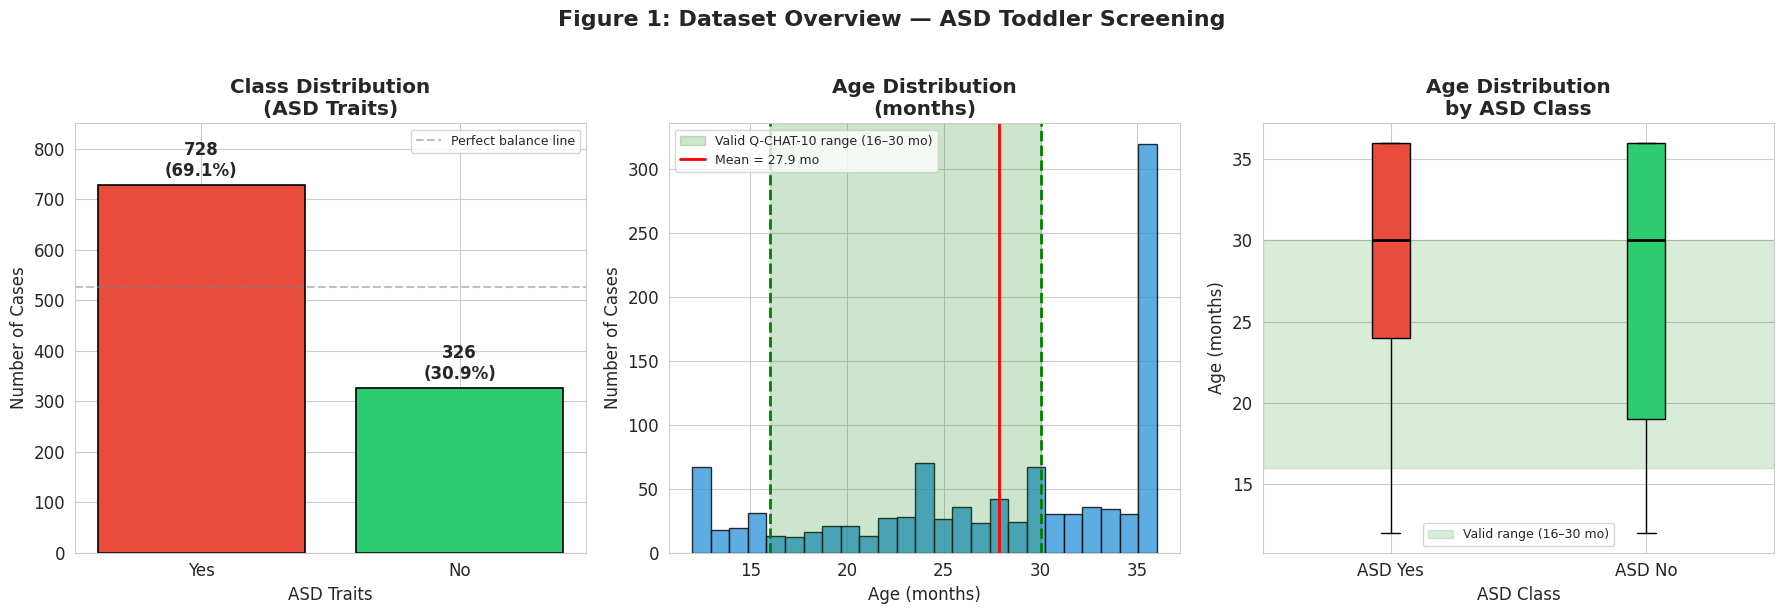

✅ Figure 1 saved as 'Figure1_Dataset_Overview.png'
   → This figure goes in your paper's Data section


In [ ]:
# ============================================================
# CELL 7: Visual EDA — Class Distribution & Age
# ------------------------------------------------------------
# WHY: Visualizations make findings undeniable. These plots
# will go directly into your paper's Data section.
# We create paper-ready figures with proper labels/titles.
#
# CLINICAL CONNECTION:
# - Class imbalance plot → shows real-world screening context
# - Age distribution → shows clinical validity of sample
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 1: Dataset Overview — ASD Toddler Screening',
             fontsize=16, fontweight='bold', y=1.02)

# ── Plot 1: Class Distribution ────────────────────────────
ax1 = axes[0]
class_counts = df['Class/ASD Traits'].value_counts()
colors = ['#e74c3c', '#2ecc71']  # Red=Yes, Green=No
bars = ax1.bar(class_counts.index, class_counts.values,
               color=colors, edgecolor='black', linewidth=1.2)

# Add count + percentage labels on bars
for bar, (label, count) in zip(bars, class_counts.items()):
    pct = count / len(df) * 100
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             f'{count}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

ax1.set_title('Class Distribution\n(ASD Traits)', fontweight='bold')
ax1.set_xlabel('ASD Traits')
ax1.set_ylabel('Number of Cases')
ax1.set_ylim(0, 850)
ax1.axhline(y=len(df)/2, color='gray', linestyle='--',
            alpha=0.5, label='Perfect balance line')
ax1.legend(fontsize=9)

# ── Plot 2: Age Distribution (Histogram) ─────────────────
ax2 = axes[1]
ax2.hist(df['Age_Mons'], bins=25, color='#3498db',
         edgecolor='black', alpha=0.8)

# Mark the valid Q-CHAT-10 range
ax2.axvspan(16, 30, alpha=0.2, color='green',
            label='Valid Q-CHAT-10 range (16–30 mo)')
ax2.axvline(x=16, color='green', linestyle='--', linewidth=2)
ax2.axvline(x=30, color='green', linestyle='--', linewidth=2)
ax2.axvline(x=df['Age_Mons'].mean(), color='red',
            linestyle='-', linewidth=2,
            label=f'Mean = {df["Age_Mons"].mean():.1f} mo')

ax2.set_title('Age Distribution\n(months)', fontweight='bold')
ax2.set_xlabel('Age (months)')
ax2.set_ylabel('Number of Cases')
ax2.legend(fontsize=9)

# ── Plot 3: Age by ASD Class (Boxplot) ───────────────────
ax3 = axes[2]
asd_yes = df[df['Class/ASD Traits'] == 'Yes']['Age_Mons']
asd_no  = df[df['Class/ASD Traits'] == 'No']['Age_Mons']

bp = ax3.boxplot([asd_yes, asd_no],
                  labels=['ASD Yes', 'ASD No'],
                  patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#2ecc71')

ax3.axhspan(16, 30, alpha=0.15, color='green',
            label='Valid range (16–30 mo)')
ax3.set_title('Age Distribution\nby ASD Class', fontweight='bold')
ax3.set_xlabel('ASD Class')
ax3.set_ylabel('Age (months)')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('Figure1_Dataset_Overview.png', dpi=300,
            bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved as 'Figure1_Dataset_Overview.png'")
print("   → This figure goes in your paper's Data section")

STEP 8A: Risk behavior prevalence — full dataset
  Item     Clinical Meaning             Risk=1 Count   Risk=1 %
  ------------------------------------------------------------
  A1       Name Response                         594      56.4%
  A2       Eye Contact                           473      44.9%
  A3       Pointing (Request)                    423      40.1%
  A4       Pointing (Share)                      540      51.2%
  A5       Pretend Play                          553      52.5%
  A6       Gaze Following                        608      57.7%
  A7       Empathic Response                     685      65.0%
  A8       First Words                           484      45.9%
  A9       Simple Gestures                       516      49.0%
  A10      Staring Behavior                      618      58.6%


STEP 8B: Risk behavior rate — ASD Yes vs ASD No
  Item      ASD Yes %   ASD No %   Difference
  ---------------------------------------------
  A1            73.1%      19.0%       +

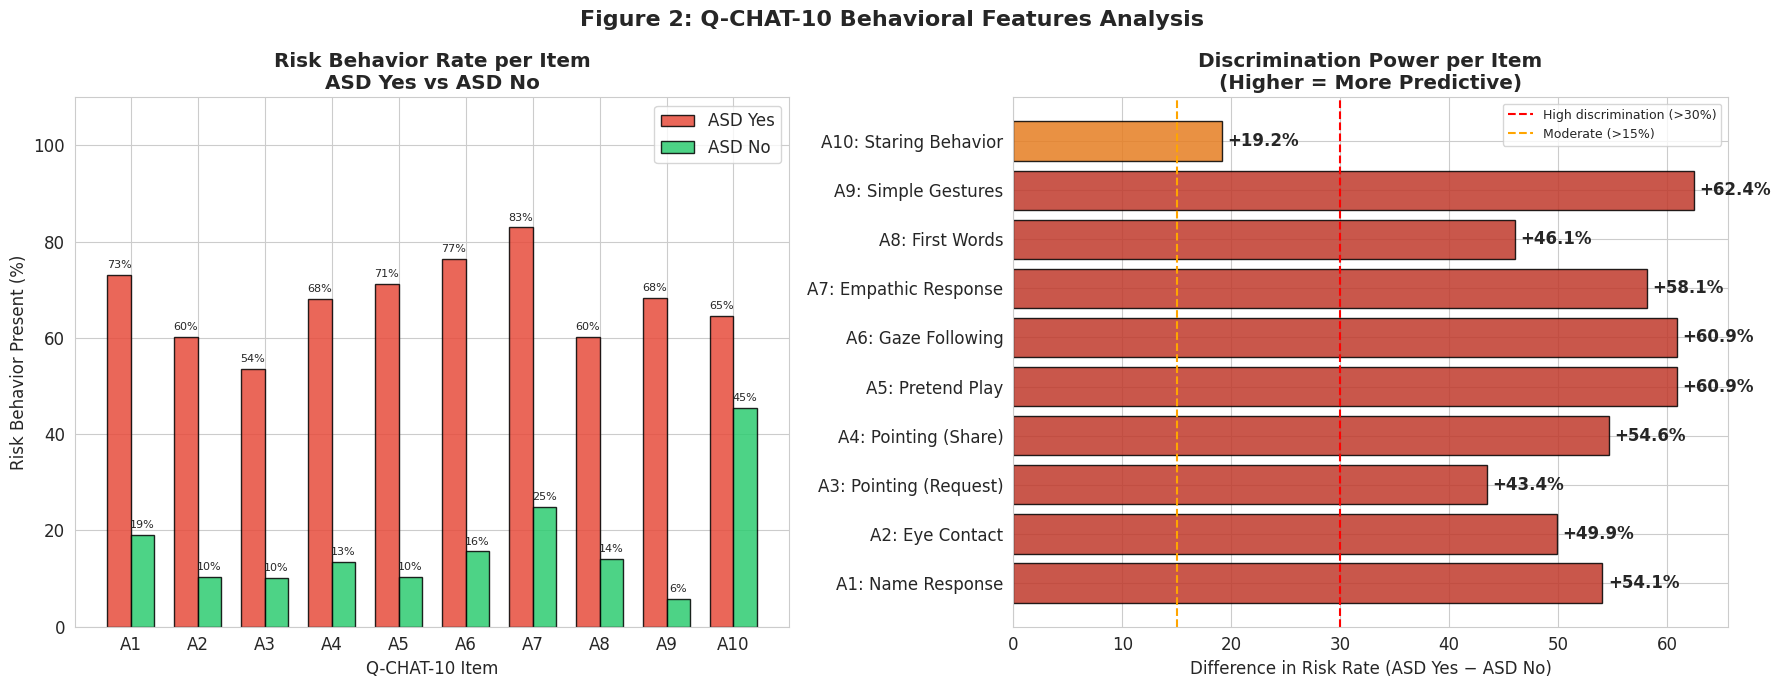

✅ Figure 2 saved as 'Figure2_QCHAT10_Analysis.png'
   → This is your key clinical finding figure for the paper


In [ ]:
# ============================================================
# CELL 8: Q-CHAT-10 Behavioral Features Analysis
# ------------------------------------------------------------
# WHY: A1–A10 are the HEART of our model. Each binary item
# maps to a DSM-5 criterion. We need to understand:
# 1. How often each risk behavior appears (prevalence)
# 2. Whether each item differs between ASD Yes vs No groups
# 3. Which items are most clinically discriminative
#
# CLINICAL CONNECTION: This analysis mirrors what a
# clinician does when reviewing Q-CHAT-10 responses —
# looking for which behaviors are most predictive.
# ============================================================

q_items = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10']

# Clinical labels for each item (for paper-ready plots)
q_labels = {
    'A1' : 'A1: Name Response',
    'A2' : 'A2: Eye Contact',
    'A3' : 'A3: Pointing (Request)',
    'A4' : 'A4: Pointing (Share)',
    'A5' : 'A5: Pretend Play',
    'A6' : 'A6: Gaze Following',
    'A7' : 'A7: Empathic Response',
    'A8' : 'A8: First Words',
    'A9' : 'A9: Simple Gestures',
    'A10': 'A10: Staring Behavior'
}

print("=" * 65)
print("STEP 8A: Risk behavior prevalence — full dataset")
print("=" * 65)
print(f"  {'Item':<8} {'Clinical Meaning':<28} {'Risk=1 Count':>12} {'Risk=1 %':>10}")
print("  " + "-"*60)
for item in q_items:
    count = df[item].sum()
    pct   = count / len(df) * 100
    label = q_labels[item].split(': ')[1]
    print(f"  {item:<8} {label:<28} {count:>12} {pct:>9.1f}%")

print("\n")
print("=" * 65)
print("STEP 8B: Risk behavior rate — ASD Yes vs ASD No")
print("=" * 65)
asd_yes = df[df['Class/ASD Traits'] == 'Yes']
asd_no  = df[df['Class/ASD Traits'] == 'No']

print(f"  {'Item':<8} {'ASD Yes %':>10} {'ASD No %':>10} {'Difference':>12}")
print("  " + "-"*45)
diff_data = {}
for item in q_items:
    yes_pct = asd_yes[item].mean() * 100
    no_pct  = asd_no[item].mean()  * 100
    diff    = yes_pct - no_pct
    diff_data[item] = diff
    marker = " ⭐" if abs(diff) > 30 else ""
    print(f"  {item:<8} {yes_pct:>9.1f}% {no_pct:>9.1f}% {diff:>+11.1f}%{marker}")

print("\n  ⭐ = Difference > 30% (highly discriminative item)")

# ── Figure 2: Q-CHAT-10 Visual Analysis ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Figure 2: Q-CHAT-10 Behavioral Features Analysis',
             fontsize=16, fontweight='bold')

# Plot 1: Grouped bar chart — ASD Yes vs No per item
ax1 = axes[0]
x     = np.arange(len(q_items))
width = 0.35

yes_rates = [asd_yes[item].mean() * 100 for item in q_items]
no_rates  = [asd_no[item].mean()  * 100 for item in q_items]

bars1 = ax1.bar(x - width/2, yes_rates, width,
                label='ASD Yes', color='#e74c3c',
                edgecolor='black', alpha=0.85)
bars2 = ax1.bar(x + width/2, no_rates,  width,
                label='ASD No',  color='#2ecc71',
                edgecolor='black', alpha=0.85)

ax1.set_xlabel('Q-CHAT-10 Item')
ax1.set_ylabel('Risk Behavior Present (%)')
ax1.set_title('Risk Behavior Rate per Item\nASD Yes vs ASD No',
              fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(q_items)
ax1.legend()
ax1.set_ylim(0, 110)

# Add value labels on bars
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{bar.get_height():.0f}%',
             ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{bar.get_height():.0f}%',
             ha='center', va='bottom', fontsize=8)

# Plot 2: Discrimination power (difference between groups)
ax2 = axes[1]
diffs  = [diff_data[item] for item in q_items]
colors = ['#c0392b' if d > 30 else '#e67e22'
          if d > 15 else '#f1c40f' for d in diffs]

bars3 = ax2.barh(q_items, diffs, color=colors,
                  edgecolor='black', alpha=0.85)
ax2.axvline(x=30, color='red', linestyle='--',
            linewidth=1.5, label='High discrimination (>30%)')
ax2.axvline(x=15, color='orange', linestyle='--',
            linewidth=1.5, label='Moderate (>15%)')

for bar, diff in zip(bars3, diffs):
    ax2.text(diff + 0.5, bar.get_y() + bar.get_height()/2,
             f'+{diff:.1f}%', va='center', fontweight='bold')

ax2.set_xlabel('Difference in Risk Rate (ASD Yes − ASD No)')
ax2.set_title('Discrimination Power per Item\n(Higher = More Predictive)',
              fontweight='bold')
ax2.set_yticklabels([q_labels[i] for i in q_items])
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('Figure2_QCHAT10_Analysis.png', dpi=300,
            bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved as 'Figure2_QCHAT10_Analysis.png'")
print("   → This is your key clinical finding figure for the paper")

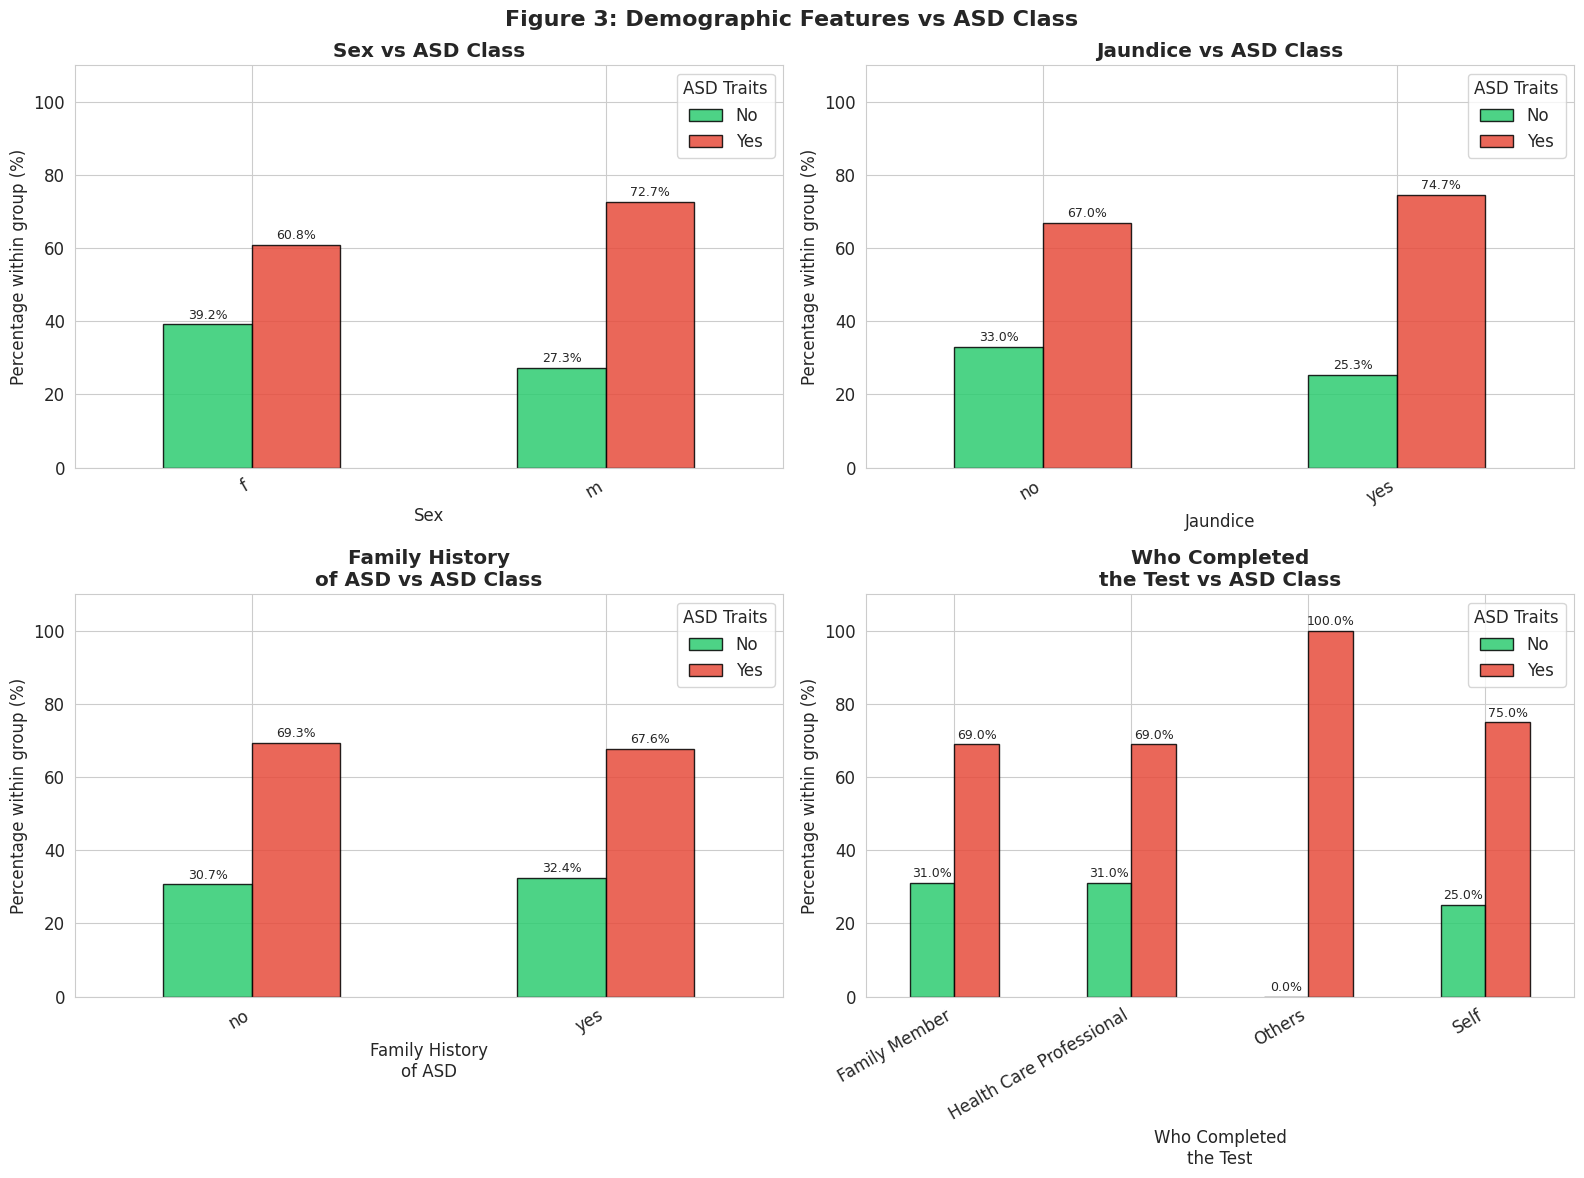

TABLE 1 DATA: Sample Characteristics
(Use these numbers in your paper's Table 1)

📊 Sex distribution:
Sex
m    735
f    319

📊 Jaundice history:
Jaundice
no     766
yes    288

📊 Family history of ASD:
Family_mem_with_ASD
no     884
yes    170

📊 Who completed the test:
Who completed the test
Family Member               1018
Health Care Professional      29
Self                           4
Others                         3

📊 ASD class by Sex:
Class/ASD Traits   No  Yes
Sex                       
f                 125  194
m                 201  534

📊 ASD class by Family History:
Class/ASD Traits      No  Yes
Family_mem_with_ASD          
no                   271  613
yes                   55  115

✅ Figure 3 saved — goes in paper's Data section
✅ Table 1 numbers printed above — copy to your paper


In [ ]:
# ============================================================
# CELL 9: Demographic Features Analysis
# ------------------------------------------------------------
# WHY: Demographics (Sex, Ethnicity, Jaundice, Family ASD)
# are not Q-CHAT-10 items but they add clinical context.
# We analyze each one to:
# 1. Describe our sample for Table 1 of the paper
# 2. Check if demographics correlate with ASD class
# 3. Identify potential bias variables
#
# CLINICAL CONNECTION:
# - Sex ratio: ASD is ~4x more common in males
# - Family history: strongest single genetic risk factor
# - Jaundice: neonatal risk factor for neurodevelopment
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Figure 3: Demographic Features vs ASD Class',
             fontsize=16, fontweight='bold')

demo_features = {
    'Sex'                  : ('Sex', ['f','m'], ['Female','Male']),
    'Jaundice'             : ('Jaundice', ['no','yes'], ['No','Yes']),
    'Family_mem_with_ASD'  : ('Family History of ASD',
                               ['no','yes'], ['No','Yes']),
    'Who completed the test': ('Who Completed Test', None, None)
}

for ax, (col, info) in zip(axes.flatten(),
                            [('Sex', 'Sex'),
                             ('Jaundice', 'Jaundice'),
                             ('Family_mem_with_ASD', 'Family History\nof ASD'),
                             ('Who completed the test',
                              'Who Completed\nthe Test')]):

    ct = pd.crosstab(df[col], df['Class/ASD Traits'],
                     normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'],
            edgecolor='black', alpha=0.85)
    ax.set_title(f'{info} vs ASD Class', fontweight='bold')
    ax.set_xlabel(info)
    ax.set_ylabel('Percentage within group (%)')
    ax.legend(title='ASD Traits', labels=['No','Yes'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30,
                       ha='right')
    ax.set_ylim(0, 110)

    # Add percentage labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=9,
                     padding=2)

plt.tight_layout()
plt.savefig('Figure3_Demographics_vs_ASD.png', dpi=300,
            bbox_inches='tight')
plt.show()

# ── Print exact numbers for Table 1 ──────────────────────
print("=" * 60)
print("TABLE 1 DATA: Sample Characteristics")
print("(Use these numbers in your paper's Table 1)")
print("=" * 60)

print(f"\n📊 Sex distribution:")
print(df['Sex'].value_counts().to_string())

print(f"\n📊 Jaundice history:")
print(df['Jaundice'].value_counts().to_string())

print(f"\n📊 Family history of ASD:")
print(df['Family_mem_with_ASD'].value_counts().to_string())

print(f"\n📊 Who completed the test:")
print(df['Who completed the test'].value_counts().to_string())

print(f"\n📊 ASD class by Sex:")
print(pd.crosstab(df['Sex'], df['Class/ASD Traits']))

print(f"\n📊 ASD class by Family History:")
print(pd.crosstab(df['Family_mem_with_ASD'],
                  df['Class/ASD Traits']))

print("\n✅ Figure 3 saved — goes in paper's Data section")
print("✅ Table 1 numbers printed above — copy to your paper")

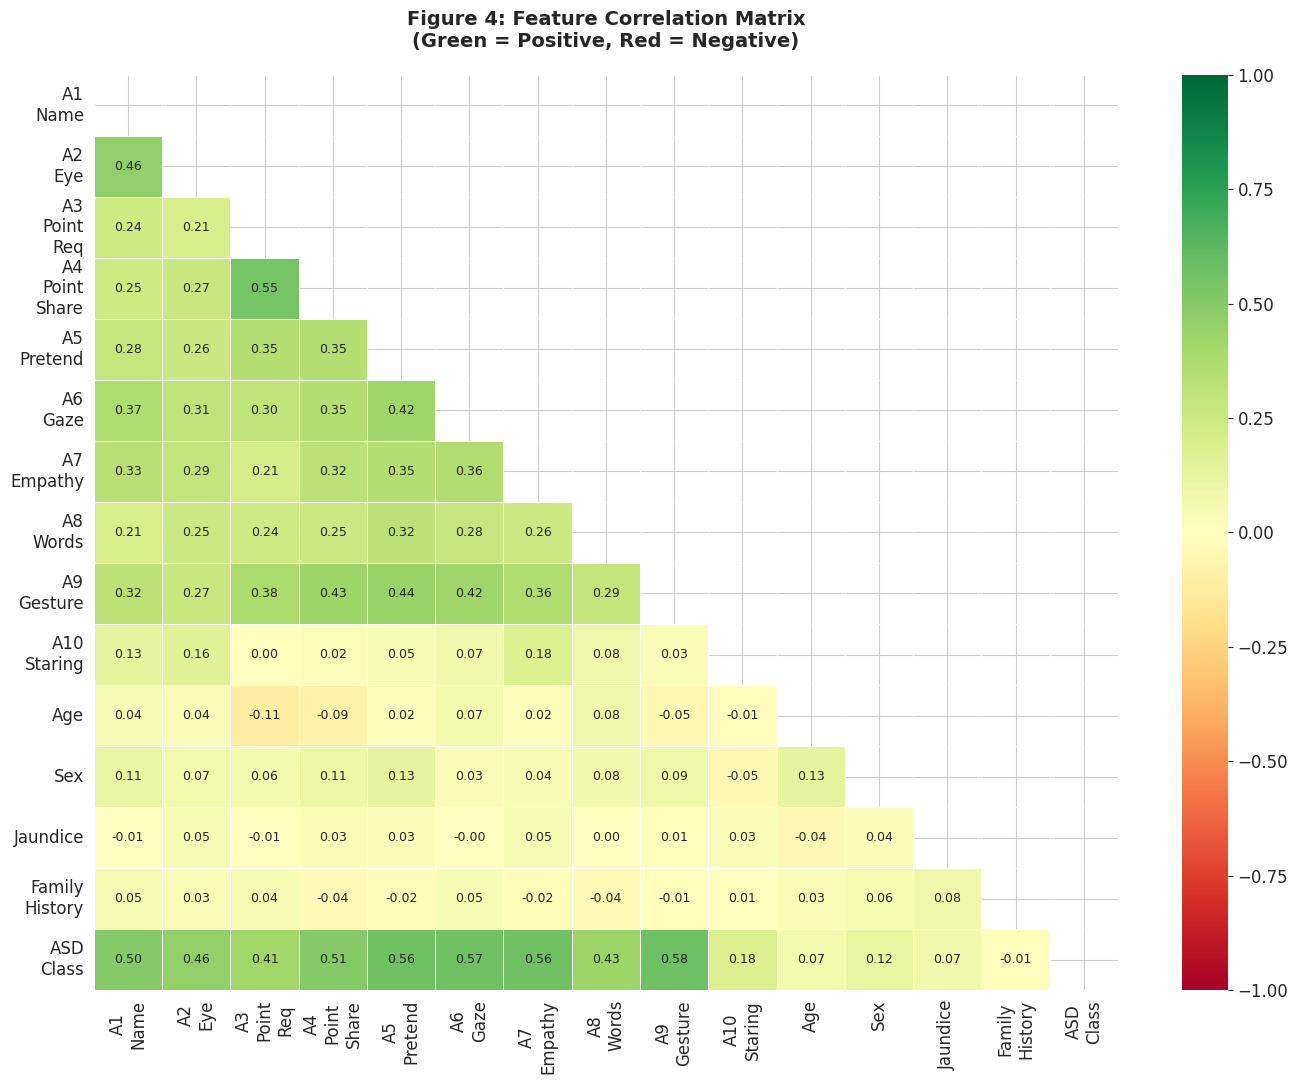

STEP 10B: Feature correlations with ASD Class
(Most important for understanding predictive power)
  A9 Gesture           +0.577  ███████████
  A6 Gaze              +0.569  ███████████
  A5 Pretend           +0.563  ███████████
  A7 Empathy           +0.563  ███████████
  A4 Point Share       +0.505  ██████████
  A1 Name              +0.504  ██████████
  A2 Eye               +0.463  █████████
  A8 Words             +0.427  ████████
  A3 Point Req         +0.410  ████████
  A10 Staring          +0.180  ███
  Sex                  +0.118  ██
  Jaundice             +0.074  █
  Age                  +0.067  █
  Family History       -0.014  

✅ Figure 4 saved as 'Figure4_Correlation_Heatmap.png'
   → Goes in paper's Methods or Appendix section


In [ ]:
# ============================================================
# CELL 10: Correlation Heatmap
# ------------------------------------------------------------
# WHY: Before building any ML model, we must understand
# how features relate to each other AND to the target.
# High correlation between features = multicollinearity
# → can hurt Logistic Regression performance
# High correlation with target = predictive power
#
# CLINICAL CONNECTION: If A5 (Pretend Play) and A6 (Gaze
# Following) are highly correlated, they may be capturing
# the same underlying behavior — important for SHAP
# interpretation later.
# ============================================================

# ── Prepare numeric dataframe for correlation ─────────────
# Encode binary categorical columns as 0/1
df_corr = df.copy()

# Encode target
df_corr['ASD'] = (df_corr['Class/ASD Traits'] == 'Yes').astype(int)

# Encode binary columns
df_corr['Sex_encoded']     = (df_corr['Sex'] == 'm').astype(int)
df_corr['Jaundice_enc']    = (df_corr['Jaundice'] == 'yes').astype(int)
df_corr['FamHistory_enc']  = (df_corr['Family_mem_with_ASD'] == 'yes').astype(int)

# Select columns for correlation
corr_cols = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10',
             'Age_Mons','Sex_encoded','Jaundice_enc',
             'FamHistory_enc','ASD']

corr_labels = ['A1\nName','A2\nEye','A3\nPoint\nReq',
               'A4\nPoint\nShare','A5\nPretend',
               'A6\nGaze','A7\nEmpathy','A8\nWords',
               'A9\nGesture','A10\nStaring',
               'Age','Sex','Jaundice','Family\nHistory','ASD\nClass']

corr_matrix = df_corr[corr_cols].corr()

# ── Figure 4: Heatmap ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # upper triangle

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            xticklabels=corr_labels,
            yticklabels=corr_labels,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 9})

ax.set_title('Figure 4: Feature Correlation Matrix\n'
             '(Green = Positive, Red = Negative)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('Figure4_Correlation_Heatmap.png', dpi=300,
            bbox_inches='tight')
plt.show()

# ── Print correlations with target only ───────────────────
print("=" * 55)
print("STEP 10B: Feature correlations with ASD Class")
print("(Most important for understanding predictive power)")
print("=" * 55)
target_corr = corr_matrix['ASD'].drop('ASD').sort_values(
                ascending=False)

for feat, corr_val in target_corr.items():
    label = corr_labels[corr_cols.index(feat)]
    label_clean = label.replace('\n', ' ')
    bar = '█' * int(abs(corr_val) * 20)
    direction = '+' if corr_val > 0 else '-'
    print(f"  {label_clean:<20} {direction}{abs(corr_val):.3f}  {bar}")

print("\n✅ Figure 4 saved as 'Figure4_Correlation_Heatmap.png'")
print("   → Goes in paper's Methods or Appendix section")

In [ ]:
# ============================================================
# CELL 11: Phase 2 Summary + Save Clean Dataset
# ------------------------------------------------------------
# WHY: Before moving to Phase 3 (ML Pipeline), we must:
# 1. Apply all cleaning decisions made during EDA
# 2. Save a clean, ML-ready dataset
# 3. Print a complete summary of all Phase 2 findings
#    for the paper
#
# This cell is the BRIDGE between EDA and ML.
# ============================================================

print("=" * 65)
print("PHASE 2 COMPLETE — CREATING CLEAN ML-READY DATASET")
print("=" * 65)

# ── Step 1: Drop leakage and ID columns ──────────────────
df_clean = df.copy()
df_clean = df_clean.drop(columns=['Case_No', 'Qchat-10-Score'])
print(f"\n✅ Dropped: Case_No (row ID) and Qchat-10-Score (leakage)")
print(f"   Columns remaining: {df_clean.shape[1]}")

# ── Step 2: Encode binary text columns → 0/1 ─────────────
df_clean['Sex']     = (df_clean['Sex'] == 'm').astype(int)
df_clean['Jaundice'] = (df_clean['Jaundice'] == 'yes').astype(int)
df_clean['Family_mem_with_ASD'] = (
    df_clean['Family_mem_with_ASD'] == 'yes').astype(int)
df_clean['Class/ASD Traits'] = (
    df_clean['Class/ASD Traits'] == 'Yes').astype(int)

print(f"\n✅ Binary encoded:")
print(f"   Sex              : m=1, f=0")
print(f"   Jaundice         : yes=1, no=0")
print(f"   Family_mem_w_ASD : yes=1, no=0")
print(f"   Class/ASD Traits : Yes=1, No=0  (TARGET)")

# ── Step 3: One-hot encode high-cardinality categoricals ─
df_clean = pd.get_dummies(df_clean,
                           columns=['Ethnicity',
                                    'Who completed the test'],
                           drop_first=False)
print(f"\n✅ One-hot encoded: Ethnicity + Who completed the test")
print(f"   Total columns now: {df_clean.shape[1]}")

# ── Step 4: Final dataset summary ────────────────────────
print(f"\n{'='*65}")
print(f"FINAL CLEAN DATASET SUMMARY")
print(f"{'='*65}")
print(f"  Shape            : {df_clean.shape[0]} rows × "
      f"{df_clean.shape[1]} columns")
print(f"  Missing values   : {df_clean.isnull().sum().sum()}")
print(f"  Target balance   : "
      f"{df_clean['Class/ASD Traits'].sum()} positive "
      f"({df_clean['Class/ASD Traits'].mean()*100:.1f}%) | "
      f"{(df_clean['Class/ASD Traits']==0).sum()} negative")
print(f"\n  All columns:")
for i, col in enumerate(df_clean.columns, 1):
    dtype = str(df_clean[col].dtype)
    print(f"    {i:2}. {col:<45} [{dtype}]")

# ── Step 5: Save clean dataset ────────────────────────────
df_clean.to_csv('ASD_Toddler_Clean.csv', index=False)
print(f"\n✅ Clean dataset saved as 'ASD_Toddler_Clean.csv'")

# ── Step 6: Phase 2 findings summary for paper ───────────
print(f"\n{'='*65}")
print("PHASE 2 KEY FINDINGS — COPY TO YOUR PAPER NOTES")
print(f"{'='*65}")
findings = [
    "1. Dataset: 1,054 instances, 19 raw columns",
    "2. Dropped: Case_No (ID) + Qchat-10-Score (leakage)",
    "3. No NaN missing values detected",
    "4. Dirty category fixed: 'Who completed the test'",
    "5. Age range violation: 615/1054 (58.3%) outside 16-30mo",
    "6. Class imbalance: ASD Yes 69.1% vs No 30.9% (2.23:1)",
    "7. Top predictors: A9(r=0.577), A6(0.569), A5(0.563)",
    "8. Weakest predictor: A10 Staring (r=0.180)",
    "9. Family history: near-zero ASD correlation (r=-0.014)",
    "10. No multicollinearity: max inter-feature r=0.55",
    "11. Ethnicity: 11 groups, White European dominant (31.7%)",
    "12. 96.6% of tests completed by family members",
]
for f in findings:
    print(f"  {f}")

print(f"\n{'='*65}")
print("✅ PHASE 2 COMPLETE")
print("   Next: Phase 3 — ML Pipeline (SVM + Logistic Regression)")
print(f"{'='*65}")

PHASE 2 COMPLETE — CREATING CLEAN ML-READY DATASET

✅ Dropped: Case_No (row ID) and Qchat-10-Score (leakage)
   Columns remaining: 17

✅ Binary encoded:
   Sex              : m=1, f=0
   Jaundice         : yes=1, no=0
   Family_mem_w_ASD : yes=1, no=0
   Class/ASD Traits : Yes=1, No=0  (TARGET)

✅ One-hot encoded: Ethnicity + Who completed the test
   Total columns now: 30

FINAL CLEAN DATASET SUMMARY
  Shape            : 1054 rows × 30 columns
  Missing values   : 0
  Target balance   : 728 positive (69.1%) | 326 negative

  All columns:
     1. A1                                            [int64]
     2. A2                                            [int64]
     3. A3                                            [int64]
     4. A4                                            [int64]
     5. A5                                            [int64]
     6. A6                                            [int64]
     7. A7                                            [int64]
     8. A8           

In [ ]:
from google.colab import files
import zipfile
import glob

zip_name = 'Phase 2 of project PR.zip'

with zipfile.ZipFile(zip_name, 'w') as zipf:
    for f in glob.glob('*.png'):
        zipf.write(f)
    for f in glob.glob('*.ipynb'):
        zipf.write(f)
    for f in glob.glob('*.csv'):
        zipf.write(f)

print(f"✅ Created: {zip_name}")
files.download(zip_name)

✅ Created: Phase 2 of project PR.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>